In [ ]:
# ==============================
# TASK 1 — DATA EXPLORATION WITH PANDAS
# ==============================

import pandas as pd

# Load dataset
df = pd.read_csv("students.csv")
df.columns = df.columns.str.strip()

# 1. First 5 rows
print("\n--- First 5 Rows ---")
print(df.head())

# 2. Shape & data types
print("\n--- Shape ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

# 3. Summary statistics
print("\n--- Summary Statistics ---")
print(df.describe())

# 4. Pass/Fail count
print("\n--- Pass/Fail Count ---")
print(df['passed'].value_counts())

# 5. Average scores per subject
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\n--- Passed Students Average ---")
print(df[df['passed'] == 1][subject_cols].mean())

print("\n--- Failed Students Average ---")
print(df[df['passed'] == 0][subject_cols].mean())

# 6. Highest average student
df['average'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['average'].idxmax()]

print("\n--- Top Student ---")
print(top_student)


--- First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- Shape ---
(15, 9)

--- Data Types ---
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
            m

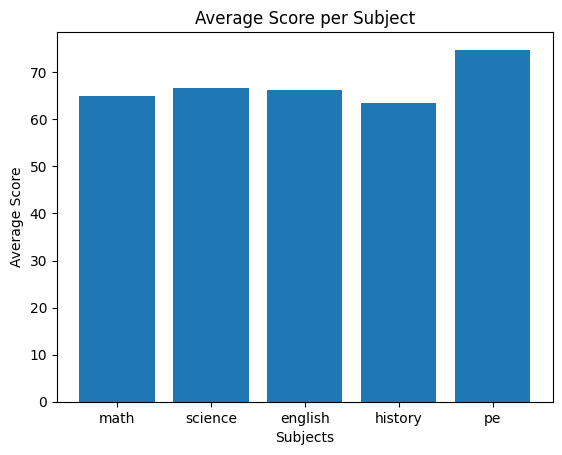

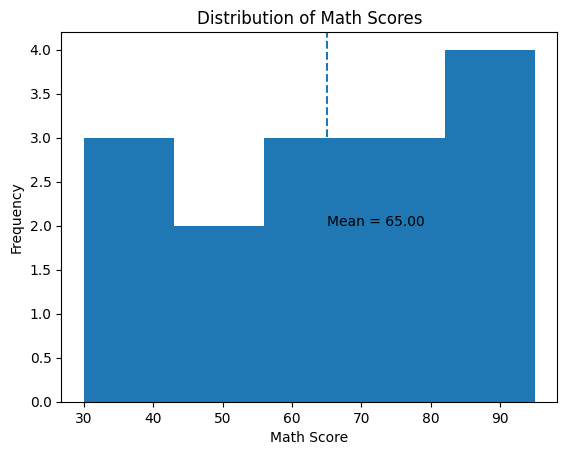

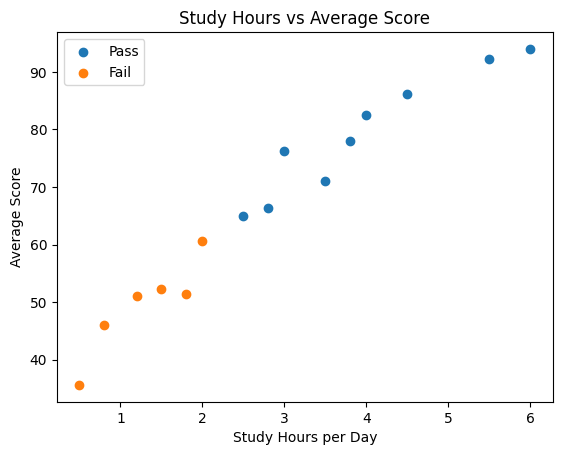

C:\Users\USER\AppData\Local\Temp\ipykernel_11204\1083897753.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


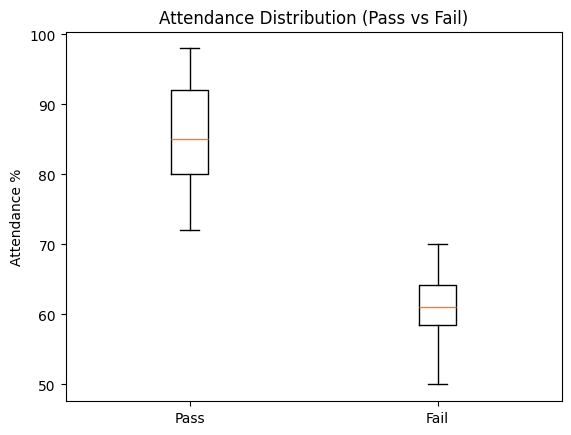

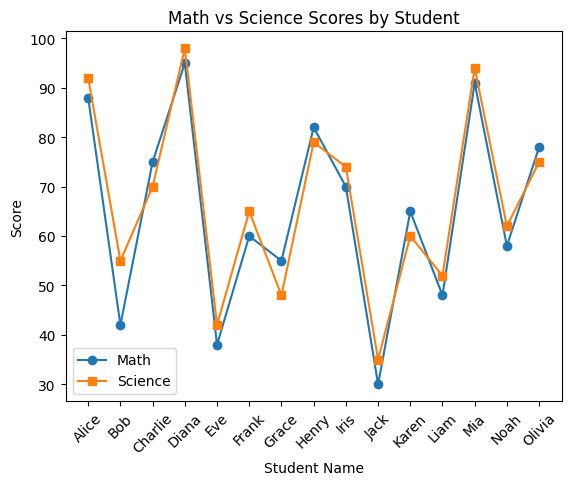

In [11]:
# ==============================
# TASK 2 — DATA VISUALIZATION
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv("students.csv",engine="python")

# Clean column names (IMPORTANT)
df.columns = df.columns.str.strip()

# Subject columns
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Add average score column
df['avg_score'] = df[subject_cols].mean(axis=1)

# ------------------------------
# 1. BAR CHART — Average score per subject
# ------------------------------
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()


# ------------------------------
# 2. HISTOGRAM — Math score distribution
# ------------------------------
plt.figure()

plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()

plt.axvline(mean_math, linestyle='dashed')
plt.text(mean_math, 2, f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.savefig("plot2_hist.png")
plt.show()


# ------------------------------
# 3. SCATTER PLOT — Study hours vs average score
# ------------------------------
plt.figure()

# Passed students
passed = df[df['passed'] == 1]
plt.scatter(passed['study_hours_per_day'], passed['avg_score'], label="Pass")

# Failed students
failed = df[df['passed'] == 0]
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()


# ------------------------------
# 4. BOX PLOT — Attendance (Pass vs Fail)
# ------------------------------
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()


# ------------------------------
# 5. LINE PLOT — Math vs Science scores
# ------------------------------
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='s', label="Science")

plt.xticks(rotation=45)

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

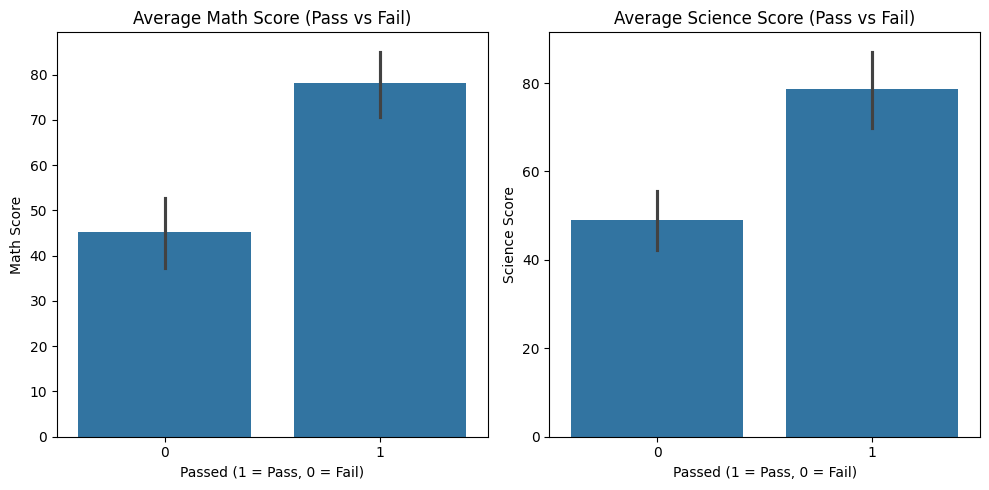

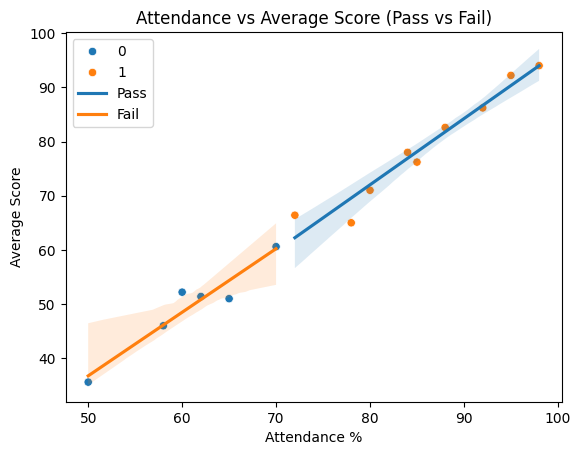

In [14]:
# ==============================
# TASK 3 — SEABORN VISUALIZATION
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv("students.csv", engine="python")

# Clean column names
df.columns = df.columns.str.strip()

# Subject columns
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Add average score column
df['avg_score'] = df[subject_cols].mean(axis=1)

# ------------------------------
# 1. BAR PLOT — Math & Science by Pass/Fail
# ------------------------------
plt.figure(figsize=(10, 5))

# Subplot 1: Math
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Average Math Score (Pass vs Fail)")
plt.xlabel("Passed (1 = Pass, 0 = Fail)")
plt.ylabel("Math Score")

# Subplot 2: Science
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Average Science Score (Pass vs Fail)")
plt.xlabel("Passed (1 = Pass, 0 = Fail)")
plt.ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()


# ------------------------------
# 2. SCATTER + REGRESSION — Attendance vs Avg Score
# ------------------------------
plt.figure()

# Scatter plot with color by passed
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression lines for each group
sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# ------------------------------
# COMMENT (Required)
# ------------------------------
# Seaborn was easier to use for statistical plots like bar charts and regression lines
# because it automatically calculates averages and adds styling.
# Compared to Matplotlib, Seaborn requires less code for complex visualizations,
# while Matplotlib gives more control but needs more manual work.


--- Training Accuracy ---
1.0

--- Test Accuracy ---
1.0

--- Predictions on Test Set ---
Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct

--- Feature Importance (sorted) ---
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


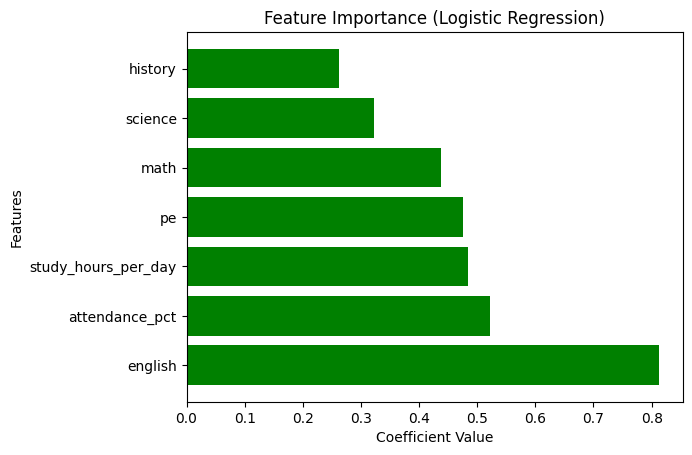


--- New Student Prediction ---
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [17]:
# ==============================
# TASK 4 — MACHINE LEARNING
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv("students.csv", engine="python")

# Clean column names
df.columns = df.columns.str.strip()

# ------------------------------
# Step 1 — Prepare Data
# ------------------------------

# Features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# Step 2 — Train Model
# ------------------------------
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# Training accuracy
train_acc = model.score(X_train_scaled, y_train)
print("\n--- Training Accuracy ---")
print(train_acc)

# ------------------------------
# Step 3 — Evaluate Model
# ------------------------------
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("\n--- Test Accuracy ---")
print(test_acc)

print("\n--- Predictions on Test Set ---")

# Get names of test students
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {status}")

# ------------------------------
# Step 4 — Feature Importance
# ------------------------------
coefficients = model.coef_[0]

# Pair features with coefficients
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance_sorted = sorted(
    feature_importance,
    key=lambda x: abs(x[1]),
    reverse=True
)

print("\n--- Feature Importance (sorted) ---")
for feature, coef in feature_importance_sorted:
    print(f"{feature}: {coef:.4f}")

# Plot feature importance
features = [f[0] for f in feature_importance_sorted]
coefs = [f[1] for f in feature_importance_sorted]

colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure()
plt.barh(features, coefs, color=colors)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("plot8_feature_importance.png")
plt.show()

# ------------------------------
# Step 5 — Predict New Student (Bonus)
# ------------------------------
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scale new data
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\n--- New Student Prediction ---")
print(f"Prediction: {result}")
print(f"Probability (Fail, Pass): {probability}")